# 13 Read-Level Linkage

**Methods mapping:** read-level support for linkage across candidate covarying sites.

This notebook summarizes spanning-read nucleotide combinations across the candidate covarying G-gene sites and redraws Supplementary Fig. S4 from the read-level linkage tables.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image as IPyImage

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('13_read_level_linkage', ROOT)
INPUTS = {
    'plot_values': DATA_DIR / 'read_level_linkage_plot_values.csv',
    'sample_label_map': DATA_DIR / 'read_level_linkage_sample_label_map.csv',
    'combo_counts_long': DATA_DIR / 'read_level_linkage_combo_counts_long.csv',
    'sample_summary': DATA_DIR / 'read_level_linkage_sample_summary.csv',
    'cohort_summary': DATA_DIR / 'read_level_linkage_cohort_summary.csv',
}
OUTPUTS = {
    'plot_values_with_labels': DATA_DIR / 'read_level_linkage_plot_values_with_sample_labels.csv',
    'figure_png': FIG_DIR / 'Supplementary_Figure_S4_read_level_linkage.png',
    'figure_pdf': FIG_DIR / 'Supplementary_Figure_S4_read_level_linkage.pdf',
    'figure_svg': FIG_DIR / 'Supplementary_Figure_S4_read_level_linkage.svg',
}
display(pd.DataFrame({'input': INPUTS.keys(), 'path': [rel(p) for p in INPUTS.values()]}))
display(pd.DataFrame({'output': OUTPUTS.keys(), 'path': [rel(p) for p in OUTPUTS.values()]}))


,input,path
0,plot_values,data/processed_data/13_read_level_linkage/read...
1,sample_label_map,data/processed_data/13_read_level_linkage/read...
2,combo_counts_long,data/processed_data/13_read_level_linkage/read...
3,sample_summary,data/processed_data/13_read_level_linkage/read...
4,cohort_summary,data/processed_data/13_read_level_linkage/read...


,output,path
0,plot_values_with_labels,data/processed_data/13_read_level_linkage/read...
1,figure_png,results/figures/13_read_level_linkage/Suppleme...
2,figure_pdf,results/figures/13_read_level_linkage/Suppleme...
3,figure_svg,results/figures/13_read_level_linkage/Suppleme...


## Read Linkage Tables

The plotting table contains, for each target sample, the proportions of the two globally dominant spanning-read patterns and all remaining patterns.


In [3]:
plot_values = pd.read_csv(INPUTS['plot_values'])
label_map = pd.read_csv(INPUTS['sample_label_map'])
combo_counts = pd.read_csv(INPUTS['combo_counts_long'])
sample_summary = pd.read_csv(INPUTS['sample_summary'])
cohort_summary = pd.read_csv(INPUTS['cohort_summary'])

display(plot_values.head())
display(combo_counts.head())
display(cohort_summary)


,project,cohort,sample_id,target_sites,n_target_sites,total_spanning_reads,parsed_alignments_until_target,n_unique_read_combos,sample_top1_combo,sample_top2_combo,n_top1,n_top2,n_rest_after_sample_top2,pct_sample_top1,pct_sample_top2,pct_sample_top2_combined,pct_rest_after_sample_top2,has_two_read_patterns,global_top1_combo,global_top2_combo,n_global_top1,n_global_top2,n_other_after_global_top2,pct_global_top1,pct_global_top2,pct_global_top2_combined,pct_other_after_global_top2
0,PRJNA1037681,Australia,SRR26779971,5510;5520;5544;5558;5563,5,351,120218,3,G-A-T-A-T,A-T-C-G-C,327,23,1,93.162393,6.552707,99.715100,0.284900,True,G-A-T-A-T,A-T-C-G-C,327,23,1,93.162393,6.552707,99.715100,0.284900
1,PRJNA1037681,Australia,SRR26779974,5510;5520;5544;5558;5563,5,714,366799,9,G-A-T-A-T,A-T-C-G-C,611,64,39,85.574230,8.963585,94.537815,5.462185,True,G-A-T-A-T,A-T-C-G-C,611,64,39,85.574230,8.963585,94.537815,5.462185
2,PRJNA1037681,Australia,SRR26779980,5510;5520;5544;5558;5563,5,999,305490,8,G-A-T-A-T,A-T-C-G-C,913,45,41,91.391391,4.504505,95.895896,4.104104,True,G-A-T-A-T,A-T-C-G-C,913,45,41,91.391391,4.504505,95.895896,4.104104
3,PRJNA1037681,Australia,SRR26779981,5510;5520;5544;5558;5563,5,508,240224,9,G-A-T-A-T,A-T-C-G-C,430,45,33,84.645669,8.858268,93.503937,6.496063,True,G-A-T-A-T,A-T-C-G-C,430,45,33,84.645669,8.858268,93.503937,6.496063
4,PRJNA1037681,Australia,SRR26779985,5510;5520;5544;5558;5563,5,722,313471,11,G-A-T-A-T,A-T-C-G-C,627,51,44,86.842105,7.063712,93.905817,6.094183,True,G-A-T-A-T,A-T-C-G-C,627,51,44,86.842105,7.063712,93.905817,6.094183


,project,cohort,sample_id,target_sites,combo_rank,combo,count,pct
0,PRJNA1037681,Australia,SRR26779971,5510;5520;5544;5558;5563,1,G-A-T-A-T,327,93.162393
1,PRJNA1037681,Australia,SRR26779971,5510;5520;5544;5558;5563,2,A-T-C-G-C,23,6.552707
2,PRJNA1037681,Australia,SRR26779971,5510;5520;5544;5558;5563,3,T-T-C-G-C,1,0.284900
3,PRJNA1037681,Australia,SRR26779974,5510;5520;5544;5558;5563,1,G-A-T-A-T,611,85.574230
4,PRJNA1037681,Australia,SRR26779974,5510;5520;5544;5558;5563,2,A-T-C-G-C,64,8.963585


,project,cohort,selection_mode,n_samples,target_sites,median_total_spanning_reads,mean_total_spanning_reads,median_unique_read_combos,median_sample_top2_pct,mean_sample_top2_pct,median_global_top2_pct,mean_global_top2_pct,median_other_after_global_top2_pct,selected_TreeCluster_combo
0,PRJNA1037681,Australia,top_treecluster_combo,23,5510;5520;5544;5558;5563,417.0,534.695652,6.0,96.511628,96.334976,96.511628,96.334976,3.488372,C4+C6
1,PRJNA1130896,United States,top_treecluster_combo,26,5531;5561,2038.5,1981.807692,4.0,99.741365,99.616991,99.741365,99.616991,0.258635,C18+C21


## Prepare Plot Table

Samples are ordered by collection date within cohort and relabeled with the AU-S/US-S labels used in the sample key.


In [4]:
plot_df = plot_values.merge(
    label_map[['project', 'sample_id', 'display_sample_id', 'global_sample_index', 'collection_dt', 'year_month', 'state', 'city', 'clade']],
    on=['project', 'sample_id'],
    how='left',
)
plot_df['display_sample_id'] = plot_df['display_sample_id'].fillna(plot_df['sample_id'])
plot_df = plot_df.sort_values(['project', 'global_sample_index', 'sample_id'])
plot_df.to_csv(OUTPUTS['plot_values_with_labels'], index=False)

display(plot_df[['project', 'display_sample_id', 'sample_id', 'target_sites', 'total_spanning_reads', 'pct_global_top1', 'pct_global_top2', 'pct_other_after_global_top2']].head(12))


,project,display_sample_id,sample_id,target_sites,total_spanning_reads,pct_global_top1,pct_global_top2,pct_other_after_global_top2
0,PRJNA1037681,AU-S01,SRR26779971,5510;5520;5544;5558;5563,351,93.162393,6.552707,0.284900
16,PRJNA1037681,AU-S02,SRR26780187,5510;5520;5544;5558;5563,1070,92.523364,5.514019,1.962617
15,PRJNA1037681,AU-S03,SRR26780146,5510;5520;5544;5558;5563,858,91.142191,6.177156,2.680653
9,PRJNA1037681,AU-S04,SRR26780067,5510;5520;5544;5558;5563,133,91.729323,6.015038,2.255639
20,PRJNA1037681,AU-S06,SRR26780216,5510;5520;5544;5558;5563,617,92.544571,3.079417,4.376013
5,PRJNA1037681,AU-S07,SRR26779994,5510;5520;5544;5558;5563,417,92.326139,3.836930,3.836930
21,PRJNA1037681,AU-S09,SRR26780219,5510;5520;5544;5558;5563,804,92.910448,3.109453,3.980100
19,PRJNA1037681,AU-S12,SRR26780211,5510;5520;5544;5558;5563,354,93.785311,2.824859,3.389831
12,PRJNA1037681,AU-S15,SRR26780123,5510;5520;5544;5558;5563,448,94.196429,3.571429,2.232143
13,PRJNA1037681,AU-S16,SRR26780126,5510;5520;5544;5558;5563,172,84.302326,12.209302,3.488372


## Figure

Supplementary Fig. S4 shows the relative abundance of the two dominant multi-site read patterns in target samples.


/tmp/ipykernel_72693/3429083623.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


Saved: results/figures/13_read_level_linkage/Supplementary_Figure_S4_read_level_linkage.png, results/figures/13_read_level_linkage/Supplementary_Figure_S4_read_level_linkage.pdf, results/figures/13_read_level_linkage/Supplementary_Figure_S4_read_level_linkage.svg

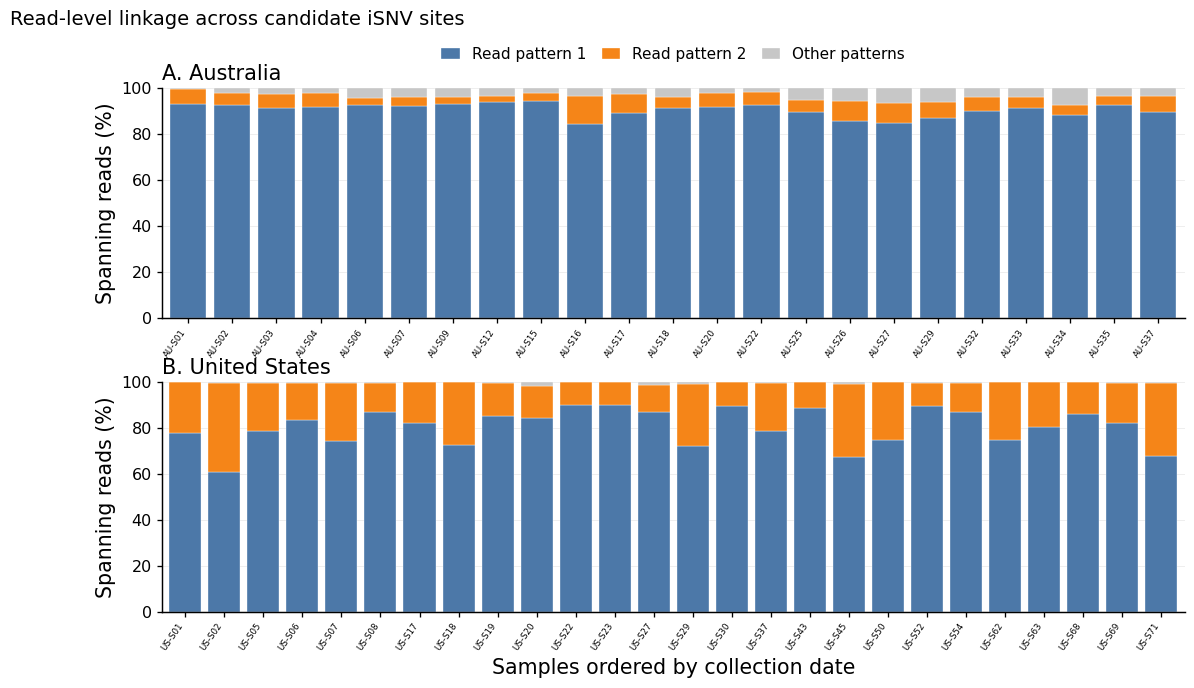

In [5]:
PROJECTS = {
    'PRJNA1037681': {'label': 'Australia'},
    'PRJNA1130896': {'label': 'United States'},
}

mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13.0,
    'axes.labelsize': 14.8,
    'axes.titlesize': 15.0,
    'xtick.labelsize': 11.5,
    'ytick.labelsize': 11.5,
    'legend.fontsize': 11.0,
    'legend.title_fontsize': 11.6,
    'axes.linewidth': 1.05,
    'xtick.major.width': 0.95,
    'ytick.major.width': 0.95,
    'xtick.major.size': 3.6,
    'ytick.major.size': 3.6,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
    'figure.facecolor': 'white',
})

fig, axes = plt.subplots(2, 1, figsize=(13.2, 6.8), sharey=True, gridspec_kw={'hspace': 0.28})
stack_cols = ['pct_global_top1', 'pct_global_top2', 'pct_other_after_global_top2']
stack_labels = ['Read pattern 1', 'Read pattern 2', 'Other patterns']
stack_colors = ['#4C78A8', '#F58518', '#C7C7C7']
for ax, (project, cfg) in zip(axes, PROJECTS.items()):
    sub = plot_df[plot_df['project'].eq(project)].copy()
    x = np.arange(len(sub))
    bottom = np.zeros(len(sub))
    for col, label, color in zip(stack_cols, stack_labels, stack_colors):
        vals = sub[col].fillna(0).to_numpy()
        ax.bar(x, vals, bottom=bottom, width=0.82, color=color, edgecolor='white', linewidth=0.25, label=label)
        bottom += vals
    ax.set_ylim(0, 100)
    ax.set_xlim(-0.6, len(sub) - 0.4)
    ax.set_ylabel('Spanning reads (%)')
    ax.set_title(f"{'A' if project == 'PRJNA1037681' else 'B'}. {cfg['label']}", loc='left', pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels(sub['display_sample_id'], rotation=55, ha='right', fontsize=6.2)
    au.clean_axis(ax)
    ax.grid(axis='y', color='#EAEAEA', lw=0.55, zorder=0)
    ax.set_axisbelow(True)
axes[0].legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.50, 1.24), columnspacing=1.0, handlelength=1.2)
axes[-1].set_xlabel('Samples ordered by collection date')
fig.suptitle('Read-level linkage across candidate iSNV sites', x=0.01, ha='left', y=0.995, fontsize=14.0)
fig.tight_layout(rect=[0, 0, 1, 0.96])
paths = au.save_pub_figure(fig, FIG_DIR, 'Supplementary_Figure_S4_read_level_linkage', dpi=450)
display(Markdown('Saved: ' + ', '.join(paths.values())))
plt.show()
